# Performance Summary — Statistical Arbitrage Research Platform

The "performance summary and benchmark comparison" notebook called for in
`specs/design-spec.md`'s Reporting Layer (Feature 6 / Phase 4's last
checklist item). It runs the full pipeline — real exchange data
(`quant_project.data`) -> signals (`quant_project.signals`) -> train/test
split and parameter selection (`quant_project.model_selection`, C3/C4 in
`specs/methodology-fixes-scope.md`) -> backtest (`quant_project.backtest`)
-> strategy combination (`quant_project.combination`) -> performance
report (`quant_project.performance`) — and charts the results, in-sample
and out-of-sample separately.

Momentum lookback, EMA fast/slow pair, and combination method are each
chosen by whichever candidate scores best (net Sharpe) on the *training*
period only — reusing `main.py`'s own selection functions directly (via
`import main`) rather than duplicating that logic here, so this notebook
can't silently drift out of sync with the script. Real daily OHLCV for a
15-coin Binance universe, cached locally after the first fetch (see
`main.py` for `SYMBOLS`/`EXCHANGE_ID`/`TIMEFRAME`/`START`).

**Known remaining issue** (out of scope for A/B/C, tracked as D in that
same scope doc): this is still a tour of the pipeline's components, not a
research write-up — no stated hypothesis, no economic rationale, just
numbers and charts. That's D1's job, deliberately sequenced after C.

**Re-run this whole notebook (Kernel -> Restart & Run All) any time the
underlying signals, backtest, selection, or combination logic changes —
every cell below recomputes from the current code (Feature 6.7).**


In [1]:
import sys
from pathlib import Path

# Jupyter kernels use the *notebook's own* directory as their working
# directory (notebooks/), not the repo root -- needed both to resolve
# main.py's own repo-root-relative cache/audit paths correctly, and so
# `import main` finds main.py at all. The imports below are necessarily
# "late" (after this path setup), hence the noqa: E402 markers.
REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

import main as pipeline  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402
import pandas as pd  # noqa: E402

from quant_project.backtest import run_multi_strategy_backtest  # noqa: E402
from quant_project.combination import combine_signals  # noqa: E402
from quant_project.model_selection import slice_backtest_result, split_prices  # noqa: E402
from quant_project.performance import build_performance_report  # noqa: E402
from quant_project.signals.momentum import (  # noqa: E402
    ema_crossover_momentum,
    time_horizon_momentum,
)
from quant_project.signals.reversal import time_horizon_reversal  # noqa: E402

prices = pipeline.load_prices()
returns = prices.pct_change()
benchmark_returns = returns[pipeline.BENCHMARK_SYMBOL]

split = split_prices(prices, train_fraction=pipeline.TRAIN_FRACTION)
print(
    f"train: {split.train_prices.index[0].date()} -> {split.train_prices.index[-1].date()}"
    f" ({len(split.train_prices)} bars)"
)
print(
    f"test:  {split.split_date.date()} -> {prices.index[-1].date()}"
    f" ({len(split.test_prices)} bars)"
)


train: 2023-01-01 -> 2025-08-16 (959 bars)
test:  2025-08-17 -> 2026-10-01 (411 bars)


## Parameter selection (training data only)

Momentum lookback and EMA fast/slow pair are each chosen by whichever
candidate has the best net Sharpe *on the training period* — never the
test period, which is what the final choice is judged on below.


In [2]:
best_lookback = pipeline._select_momentum_lookback(prices, returns, split)
best_fast, best_slow = pipeline._select_ema_pair(prices, returns, split)
print(
    f"Selected on training data: momentum lookback={best_lookback}d, "
    f"EMA pair=({best_fast}, {best_slow})"
)

signals = {
    "momentum": time_horizon_momentum(prices, lookback=best_lookback),
    "ema_crossover": ema_crossover_momentum(prices, fast_span=best_fast, slow_span=best_slow),
    "reversal_1d": time_horizon_reversal(prices, lookback=1),
}
results = run_multi_strategy_backtest(signals, returns)
list(results.keys())


Selected on training data: momentum lookback=21d, EMA pair=(16, 48)


['momentum', 'ema_crossover', 'reversal_1d']

## Strategy combination: method selection + in-sample vs. out-of-sample

The combination method (equal / inverse-vol / IC) is likewise chosen by
training-period Sharpe only.


In [3]:
best_method = pipeline._select_combination_method(signals, results, returns, split)
print(f"Selected combination method on training data: {best_method}")

combo_kwargs = {
    "equal": {},
    "inverse_vol": {"strategy_returns": {n: r.net_returns for n, r in results.items()}},
    "ic": {"forward_returns": returns},
}[best_method]
combined_signal = combine_signals(signals, method=best_method, **combo_kwargs)
combined_result = run_multi_strategy_backtest({best_method: combined_signal}, returns)[best_method]

all_results = {**results, f"combined_{best_method}": combined_result}
list(all_results.keys())


Selected combination method on training data: inverse_vol


['momentum', 'ema_crossover', 'reversal_1d', 'combined_inverse_vol']

## Metrics table (6.2-6.5), in-sample vs. out-of-sample (C3/C4)

Every strategy and the combined portfolio, reported *separately* for the
training and test periods — never one blended number. A strategy whose
training-period numbers look good but whose test-period numbers collapse
is exactly the overfitting pattern this split exists to catch (watch
`ema_crossover` below, for instance).


In [4]:
rows = {}
for name, result in all_results.items():
    train_result = slice_backtest_result(result, split.train_prices.index)
    test_result = slice_backtest_result(result, split.test_prices.index)
    for period, sliced in [("train", train_result), ("test", test_result)]:
        report = build_performance_report(sliced, benchmark_returns=benchmark_returns)
        rows[(name, period)] = {
            "cum_net": report.cumulative_net.iloc[-1],
            "ann_return": report.annualized_return,
            "ann_vol": report.annualized_volatility,
            "sharpe": report.sharpe_ratio,
            "max_drawdown": report.max_drawdown,
            "alpha": report.alpha,
            "beta": report.beta,
            "alpha_t_stat": report.alpha_t_stat,
            "correlation": report.correlation,
        }

metrics = pd.DataFrame(rows).T
metrics.index.names = ["strategy", "period"]
metrics.style.format(
    {
        "cum_net": "{:+.2%}",
        "ann_return": "{:+.2%}",
        "ann_vol": "{:.2%}",
        "sharpe": "{:+.2f}",
        "max_drawdown": "{:.2%}",
        "alpha": "{:+.2%}",
        "beta": "{:+.2f}",
        "alpha_t_stat": "{:+.2f}",
        "correlation": "{:+.2f}",
    }
)


## Gross vs. net-of-cost cumulative returns (6.1)

The dashed vertical line marks the train/test split — everything to its
right is out-of-sample.


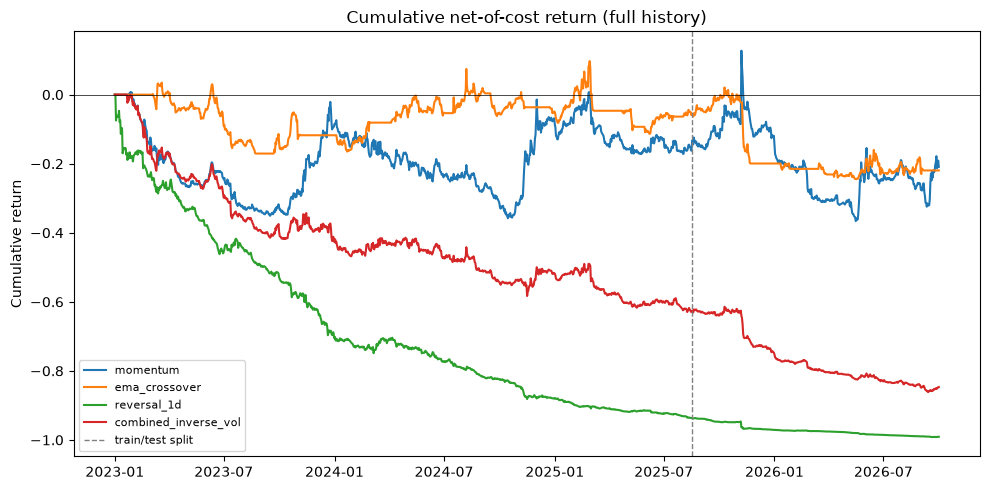

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, result in all_results.items():
    report = build_performance_report(result, benchmark_returns=benchmark_returns)
    ax.plot(report.cumulative_net.index, report.cumulative_net.values, label=name)
ax.axvline(split.split_date, color="gray", linestyle="--", linewidth=1, label="train/test split")
ax.set_title("Cumulative net-of-cost return (full history)")
ax.set_ylabel("Cumulative return")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()


## Drawdown (6.4 / 6.6)


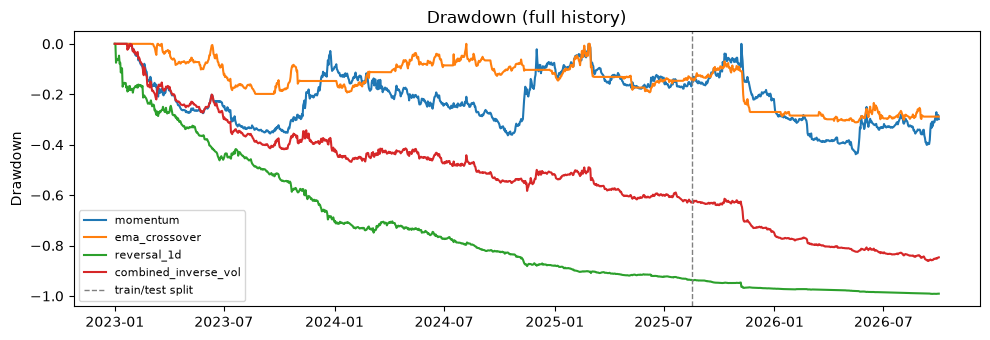

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.5))
for name, result in all_results.items():
    report = build_performance_report(result, benchmark_returns=benchmark_returns)
    ax.plot(report.drawdown.index, report.drawdown.values, label=name)
ax.axvline(split.split_date, color="gray", linestyle="--", linewidth=1, label="train/test split")
ax.set_title("Drawdown (full history)")
ax.set_ylabel("Drawdown")
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()
